In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset
df = pd.read_csv("../data/transactions.csv")

In [3]:
df.head()

,Date,Description,Category,Amount,Type
0,2026-05-01,Zomato,Food,450,Debit
1,2026-05-01,Salary,Income,50000,Credit
2,2026-05-02,Uber,Travel,220,Debit
3,2026-05-03,Amazon,Shopping,1999,Debit
4,2026-05-04,Netflix,Entertainment,649,Debit


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         10 non-null     str  
 1   Description  10 non-null     str  
 2   Category     10 non-null     str  
 3   Amount       10 non-null     int64
 4   Type         10 non-null     str  
dtypes: int64(1), str(4)
memory usage: 532.0 bytes


In [5]:
df.describe()

,Amount
count,10.000000
mean,6973.700000
std,15522.650068
min,220.000000
25%,499.750000
50%,1149.500000
75%,1949.250000
max,50000.000000


In [6]:
df["Amount"]

0      450
1    50000
2      220
3     1999
4      649
5      320
6     1800
7    12000
8      799
9     1500
Name: Amount, dtype: int64

In [7]:
type(df["Amount"])

pandas.Series

In [8]:
df[["Date", "Amount"]]

,Date,Amount
0,2026-05-01,450
1,2026-05-01,50000
2,2026-05-02,220
3,2026-05-03,1999
4,2026-05-04,649
5,2026-05-05,320
6,2026-05-06,1800
7,2026-05-07,12000
8,2026-05-08,799
9,2026-05-09,1500


In [9]:
# FILTER Large expenses
df[df["Amount"] > 1000]


#Pandas keeps only:

#True rows

#This is called:

#Boolean Indexing

#Core Pandas skill.


,Date,Description,Category,Amount,Type
1,2026-05-01,Salary,Income,50000,Credit
3,2026-05-03,Amazon,Shopping,1999,Debit
6,2026-05-06,Electricity Bill,Utilities,1800,Debit
7,2026-05-07,Freelance Payment,Income,12000,Credit
9,2026-05-09,Gym Membership,Health,1500,Debit


In [10]:
# Food expenses only
df[df["Category"] == "Food"]

,Date,Description,Category,Amount,Type
0,2026-05-01,Zomato,Food,450,Debit
5,2026-05-05,Swiggy,Food,320,Debit


In [11]:
# Debit transactions
df[df["Type"] == "Debit"]

,Date,Description,Category,Amount,Type
0,2026-05-01,Zomato,Food,450,Debit
2,2026-05-02,Uber,Travel,220,Debit
3,2026-05-03,Amazon,Shopping,1999,Debit
4,2026-05-04,Netflix,Entertainment,649,Debit
5,2026-05-05,Swiggy,Food,320,Debit
6,2026-05-06,Electricity Bill,Utilities,1800,Debit
8,2026-05-08,Bookstore,Education,799,Debit
9,2026-05-09,Gym Membership,Health,1500,Debit


In [12]:
# Credit transactions
df[df["Type"] == "Credit"]

,Date,Description,Category,Amount,Type
1,2026-05-01,Salary,Income,50000,Credit
7,2026-05-07,Freelance Payment,Income,12000,Credit


In [13]:
# Food expenses above 300
df[(df["Category"] == "Food") & (df["Amount"] > 300)]

,Date,Description,Category,Amount,Type
0,2026-05-01,Zomato,Food,450,Debit
5,2026-05-05,Swiggy,Food,320,Debit


In [14]:
# Sorting data according to highest expenses first (decreasing)
df.sort_values(by="Amount", ascending=False)

,Date,Description,Category,Amount,Type
1,2026-05-01,Salary,Income,50000,Credit
7,2026-05-07,Freelance Payment,Income,12000,Credit
3,2026-05-03,Amazon,Shopping,1999,Debit
6,2026-05-06,Electricity Bill,Utilities,1800,Debit
9,2026-05-09,Gym Membership,Health,1500,Debit
8,2026-05-08,Bookstore,Education,799,Debit
4,2026-05-04,Netflix,Entertainment,649,Debit
0,2026-05-01,Zomato,Food,450,Debit
5,2026-05-05,Swiggy,Food,320,Debit
2,2026-05-02,Uber,Travel,220,Debit


In [15]:
#Adding new column for tax (only on debit transactions)
df["Tax"] = df.apply(
    lambda row: row["Amount"] * 0.18 if row["Type"] == "Debit" else 0,
    axis=1
)
df

,Date,Description,Category,Amount,Type,Tax
0,2026-05-01,Zomato,Food,450,Debit,81.00
1,2026-05-01,Salary,Income,50000,Credit,0.00
2,2026-05-02,Uber,Travel,220,Debit,39.60
3,2026-05-03,Amazon,Shopping,1999,Debit,359.82
4,2026-05-04,Netflix,Entertainment,649,Debit,116.82
5,2026-05-05,Swiggy,Food,320,Debit,57.60
6,2026-05-06,Electricity Bill,Utilities,1800,Debit,324.00
7,2026-05-07,Freelance Payment,Income,12000,Credit,0.00
8,2026-05-08,Bookstore,Education,799,Debit,143.82
9,2026-05-09,Gym Membership,Health,1500,Debit,270.00


In [16]:
# Converting dates
df["Date"] = pd.to_datetime(df["Date"]) 

# Extracting date features
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day_name()
df

,Date,Description,Category,Amount,Type,Tax,Month,Day
0,2026-05-01,Zomato,Food,450,Debit,81.00,5,Friday
1,2026-05-01,Salary,Income,50000,Credit,0.00,5,Friday
2,2026-05-02,Uber,Travel,220,Debit,39.60,5,Saturday
3,2026-05-03,Amazon,Shopping,1999,Debit,359.82,5,Sunday
4,2026-05-04,Netflix,Entertainment,649,Debit,116.82,5,Monday
5,2026-05-05,Swiggy,Food,320,Debit,57.60,5,Tuesday
6,2026-05-06,Electricity Bill,Utilities,1800,Debit,324.00,5,Wednesday
7,2026-05-07,Freelance Payment,Income,12000,Credit,0.00,5,Thursday
8,2026-05-08,Bookstore,Education,799,Debit,143.82,5,Friday
9,2026-05-09,Gym Membership,Health,1500,Debit,270.00,5,Saturday


Now we can analyze:

weekend spending,
monthly trends,
weekday patterns.

In [19]:
# Now grouping data per category
# Total spending per category ->
df.groupby("Category")["Amount"].sum()

Category
Education          799
Entertainment      649
Food               770
Health            1500
Income           62000
Shopping          1999
Travel             220
Utilities         1800
Name: Amount, dtype: int64

In [27]:
# Total spending
total_spending = df[df["Type"] == "Debit"]["Amount"].sum()

# Total income
total_income = df[df["Type"] == "Credit"]["Amount"].sum()

# Total savings
total_savings = total_income - total_spending

print("Expenditure: ",total_spending)
print("Income: ",total_income)

print("Savings: ",total_savings)

Expenditure:  7737
Income:  62000
Savings:  54263


In [43]:
# Top Spending Category
debit_df = df[df["Type"] == "Debit"]
debit_df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

Category
Shopping         1999
Utilities        1800
Health           1500
Education         799
Food              770
Entertainment     649
Travel            220
Name: Amount, dtype: int64

In [44]:
# Top Spending Day
debit_df.groupby("Date")["Amount"].sum().idxmax()

Timestamp('2026-05-03 00:00:00')

# Visualization

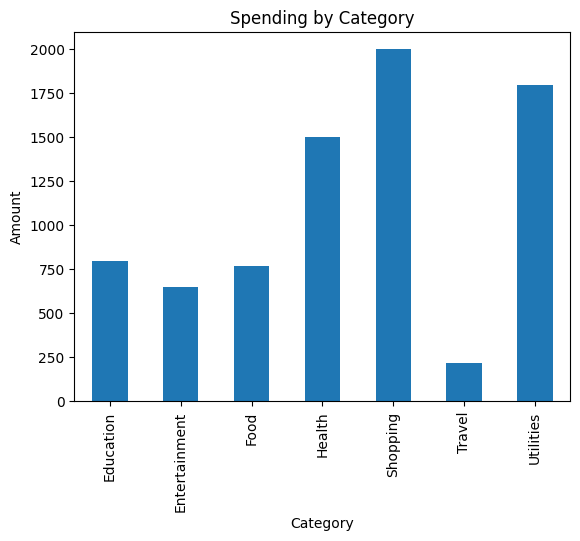

In [46]:
category_spending = debit_df.groupby("Category")["Amount"].sum()

category_spending.plot(kind="bar")

plt.title("Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.show()